In [ ]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 2. Change the current working directory to the sandbox folder
import os
# Update this path if you placed the folder somewhere else in your Drive
repo_path = '/content/drive/MyDrive/dl-gen-lyrics'
sandbox_path = os.path.join(repo_path, 'sandbox')
os.chdir(sandbox_path)
print("Current Working Directory:", os.getcwd())

# 3. Add the 'src' directory to the Python path so local imports work
import sys
src_path = os.path.abspath(os.path.join(repo_path, 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)

Current Working Directory: /content/drive/MyDrive/dl-gen-lyrics/sandbox


In [ ]:
# 4. Install requirements (optional but recommended)
# !pip install -r ../requirements.txt
!pip install -q contractions>=0.1.73
!pip install -q bert-score>=0.3.13
!pip install mauve-text>=0.3.0
!pip install json5

In [ ]:
import os, re, sys, traceback, csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sentencepiece as spm

from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data

os.getcwd()

'/content/drive/MyDrive/dl-gen-lyrics/sandbox'

In [ ]:
import generator_core as core
from aspect_midnight import Word2Vec_SkipGram, ArrayToDatasetForW2V
from aspect_tetra import *
from aspect_cobalt import Cobalt

In [ ]:
try:
    batch_count = 20*1024
    genres = {'rap', 'rb', 'pop', 'country', 'rock', 'misc'}
    print(genres)
    print(batch_count)
except:
    traceback.print_exc()

{'pop', 'rb', 'rap', 'country', 'misc', 'rock'}
20480


In [ ]:
try:
    total_subset_size = 100000
    total_group_size = total_subset_size // len(genres) + 1
    max_songs_per_artist = 50
except:
    traceback.print_exc()

In [ ]:
try:
    ds_subset = pd.read_csv(os.path.join('temp', 'genius_lyrics_subset.csv'))
    display(ds_subset.head())
except:
    traceback.print_exc()

,Unnamed: 0,title,tag,artist,year,lyrics,id,language
0,123725,In Memory of W. B. Yeats,misc,W. H. Auden,2013,I\n\nHe disappeared in the dead of winter:\nTh...,134446,en
1,2614099,Sthlm City,pop,Rebecca & Fiona,2018,"[Intro]\nI mean, like, it's okay\nOne day, you...",3931557,en
2,2550228,Fallin 2010,pop,Mozhdah,2010,[Verse 1]\nCan you take it easy\nWhile I make ...,3840000,en
3,3539706,Can the Circle Be Unbroken,country,Johnny Cash,1982,I was standing by the window\nOn one cold and ...,5350667,en
4,2650114,Marijuana,pop,Jah Cure,2019,[Intro: Jah Cure]\nOne puff one draw\nFrees th...,3982786,en


In [ ]:
try:
    cobalt = Cobalt(ds_subset)
except:
    traceback.print_exc()

Loaded Cache for Midnight._prepare_ds_data.cached
Loaded Cache for Midnight._get_custom_tokens.cached
Loaded Cache for Midnight._get_genre_dict.cached
Loaded Cache for Midnight._prepare_tfidf.cached
Loaded Cache for Midnight._prepare_vocabulary temp/lyrics_sp.model
Loaded Cache for Midnight._prepare_embedder.cached
Loaded Cache for Cobalt._prepare_training_data.cached
Loaded Cache for Cobalt._prepare_language_model.cached


In [ ]:
try:
    print(cobalt.training_data.head())
except:
    traceback.print_exc()

0    [17, 2660, 68, 15, 2855, 26, 902, 16, 17, 1796...
1    [17, 2660, 68, 15, 1951, 1119, 16, 17, 1796, 1...
2    [17, 2660, 68, 15, 1951, 1119, 16, 17, 1796, 1...
3    [17, 2660, 68, 15, 7403, 297, 5743, 16, 17, 17...
4    [17, 2660, 68, 15, 1951, 1119, 16, 17, 1796, 1...
Name: tag, dtype: object


In [ ]:
try:
    train_language_model = True
    print(cobalt.language_model)
except:
    traceback.print_exc()

BiGRULyricsModel(vocab=16000, embed=512, hidden=512, layers=2, params=11,623,552)


In [ ]:
print("Language Model Parameters:", cobalt.get_language_model_parameter_count())
print("Embedder Parameters:", cobalt.get_embedder_parameter_count())

Language Model Parameters: 3431552
Embedder Parameters: 8192000


In [ ]:
# Print the batch size used by the DataLoader
print("Batch Size:", cobalt.language_model.trainer.train_dataloader.batch_size)

# Print the sequence length used by the LyricsDataset
print("Sequence Length:", cobalt.language_model.trainer.train_dataloader.dataset.seq_len)

Batch Size: 20
Sequence Length: 1024


In [ ]:
try:
    if train_language_model:

        cobalt.language_model.trainer.device = 'cuda'

        for pg in cobalt.language_model.trainer.optimizer.param_groups:
            # pg['lr'] = 0.0001
            print(pg['lr'])

        cobalt.language_model.embedding.weight.requires_grad = True
        print(cobalt.language_model.embedding.weight.requires_grad)

except:
    traceback.print_exc()

0.0003
True


In [ ]:
try:
    if train_language_model:
        cobalt.language_model.trainer.train()
except:
    traceback.print_exc()

Epoch:  0/10    Train Loss: 3.16    TTS: 10.27    ETA: 524427.17
Epoch:  0/10    Train Loss: 3.19    TTS: 10.84    ETA: 276743.55
Epoch:  0/10    Train Loss: 3.20    TTS: 11.42    ETA: 194403.74
Epoch:  0/10    Train Loss: 2.97    TTS: 12.02    ETA: 153344.31
Epoch:  0/10    Train Loss: 3.43    TTS: 12.60    ETA: 128594.05
Epoch:  0/10    Train Loss: 3.14    TTS: 13.18    ETA: 112164.77
Epoch:  0/10    Train Loss: 3.27    TTS: 13.76    ETA: 100343.52
Epoch:  0/10    Train Loss: 3.08    TTS: 14.34    ETA: 91521.09
Epoch:  0/10    Train Loss: 3.27    TTS: 14.93    ETA: 84655.02
Epoch:  0/10    Train Loss: 3.26    TTS: 15.52    ETA: 79192.35
Epoch:  0/10    Train Loss: 3.18    TTS: 16.11    ETA: 74730.65
Epoch:  0/10    Train Loss: 3.20    TTS: 16.69    ETA: 70977.32
Epoch:  0/10    Train Loss: 3.07    TTS: 17.28    ETA: 67834.40
Epoch:  0/10    Train Loss: 3.02    TTS: 17.86    ETA: 65107.96
Epoch:  0/10    Train Loss: 3.00    TTS: 18.45    ETA: 62787.04
Epoch:  0/10    Train Loss: 3.05 

Traceback (most recent call last):
  File "/tmp/ipykernel_3053/170530448.py", line 3, in <cell line: 0>
    cobalt.language_model.trainer.train()
  File "/content/drive/MyDrive/dl-gen-lyrics/src/dl_trainer/trainer.py", line 193, in train
    self._train_step(epoch)
  File "/content/drive/MyDrive/dl-gen-lyrics/src/dl_trainer/trainer.py", line 257, in _train_step
    self.on_batch_callback(self.model, epoch, i)
  File "/content/drive/MyDrive/dl-gen-lyrics/src/aspect_tetra/training/../../aspect_cobalt/cobalt.py", line 79, in cache_checkpoint_callback
    key_cached('cached', lambda: model_ref, group='Cobalt._prepare_language_model')
  File "/content/drive/MyDrive/dl-gen-lyrics/src/generator_core/other_utilities.py", line 64, in key_cached
    _write_object(data, os.path.join(root, f"{key}.{_bone_to_ext[bone]}"), bone)
  File "/content/drive/MyDrive/dl-gen-lyrics/src/generator_core/other_utilities.py", line 18, in _write_object
    case _: pickle.dump(data, open(file, 'wb'))
            ^^

In [ ]:
try:
    if train_language_model:
        rewrite_language_model_cache = True
        if rewrite_language_model_cache:
            flight = 'Cobalt._prepare_language_model.cached'
            for file in ['bone', 'pkl']:
                file = os.path.join('temp', f'{flight}.{file}')
                if os.path.exists(file): os.remove(file)
            core.key_cached('cached', lambda: cobalt.language_model, group='Cobalt._prepare_language_model')
            print("Saved")
except:
    traceback.print_exc()

Saved


In [ ]:
try:
    print(cobalt.inference('rock', ['black', 'enter', 'spell', 'priests', 'dragon'], max_len=400).replace(' <NEW_LINE> ', '\n'))
except:
    traceback.print_exc()

<genre_rock> <theme_black> <theme_enter> <theme_spell> <theme_priests> <theme_dragon> <SONG_START> <VERSE>
here we are the night with fire
it's written on the walls that you're there
look in that you are in a light so i can get
into everything i am doing what i will ...
[ chrous ]
i want to know
i'm lost in all kinds of people
i could follow myself if you are the man i was there
<VERSE>
i believe
i feel it
i see it is so much at me , it can't be here
and i'm so afraid
but it's not me , i'm always afraid , it's not fair
all that i've ever felt on you
the world is spinning and in my mind
i let it all go away
i can't be happy i can go there alone
i know there'll be more than yesterday
with no one could stop in all of my love
my love is no new beginning
yeah , yeah
yeah , if i ever had a friend , my friend , that's my friend , my friend <NEW_


In [ ]:
try:
    if train_language_model:
        timers = cobalt.language_model.trainer.timer.timers
        for key in timers:
            print(key, timers[key].average)
except:
    traceback.print_exc()

train 0.0
_train_step 0.0
train_dataloader 0.007929001426328982
batch 1.2582033452766326


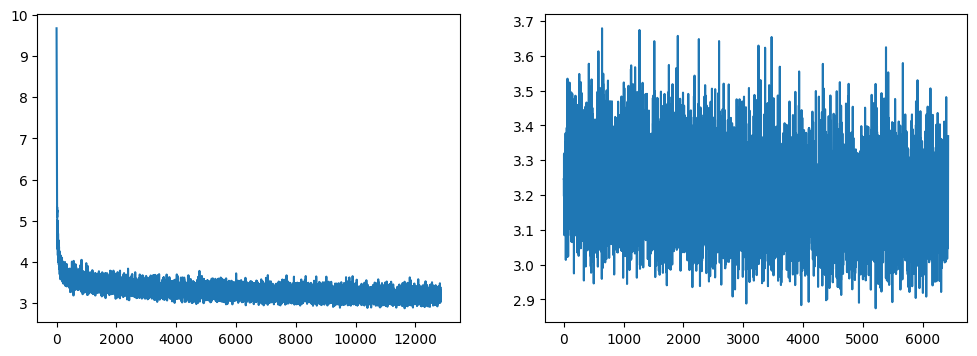

In [ ]:
try:
    if train_language_model:
        loss = cobalt.language_model.trainer.loss
        fig, axs = plt.subplots(1, 2, figsize=(12, 4))
        axs[0].plot(loss['train.batch'])
        axs[1].plot(loss['train.batch'][int(0.5 * len(loss['train.batch'])):])
        plt.show()
except:
    traceback.print_exc()

In [ ]:
# Assuming your Cobalt instance is called 'cobalt'
cobalt.generate_evaluation_samples(
    output_file="llm_evaluation_samples.txt",
    n_songs=10,
    max_len=400,      # Give it room to generate a decently sized song
    temperature=1.0   # Standard temperature for creative text generation
)

Generating song 1/10 [Genre: pop, Themes: ['o', 'lamb', 'come']]...


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1415: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1480.)
  result = _VF.gru(


Generating song 2/10 [Genre: rb, Themes: ['let', "want's", 'gotta']]...
Generating song 3/10 [Genre: pop, Themes: ['ignored', 'distracted', 'clandestine']]...
Generating song 4/10 [Genre: misc, Themes: ['shelf', 'girl', 'type']]...
Generating song 5/10 [Genre: pop, Themes: ['midnight', 'medicine', 'remedy']]...
Generating song 6/10 [Genre: rap, Themes: ['gucci', 'paula', 'deen']]...
Generating song 7/10 [Genre: country, Themes: ['tree', 'apple', 'chapel']]...
Generating song 8/10 [Genre: pop, Themes: ['life', 'hard', 'housewife']]...
Generating song 9/10 [Genre: rap, Themes: ['ya', 'niggas', 'dog']]...
Generating song 10/10 [Genre: rock, Themes: ['won', 'loved', 'yesterday']]...
Successfully saved 10 songs to llm_evaluation_samples.txt


In [ ]:
evaluator = SolutionEvaluator(cobalt)

In [ ]:
evaluator.compute_perplexity(n_sample=100, batch_size=10)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1415: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1480.)
  result = _VF.gru(


np.float64(9.210328149795533)

In [ ]:
evaluator.compute_self_bleu(n_sample=100, batch_size=10)

np.float64(0.08562993053939343)

In [ ]:
evaluator.compute_bertscore(n_sample=100, batch_size=10)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1415: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1480.)
  result = _VF.gru(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{'precision': np.float64(0.7441785931587219),
 'recall': np.float64(0.6477471351623535),
 'f1': np.float64(0.6915319085121154)}

In [ ]:
evaluator.compute_mauve(n_sample=100, batch_size=10)

Featurizing p:   0%|          | 0/10 [00:00<?, ?it/s]

Featurizing q:   0%|          | 0/10 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1415: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1480.)
  result = _VF.gru(


Featurizing p:   0%|          | 0/10 [00:00<?, ?it/s]

Featurizing q:   0%|          | 0/10 [00:00<?, ?it/s]

...

Featurizing q:   0%|          | 0/10 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1415: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1480.)
  result = _VF.gru(


Featurizing p:   0%|          | 0/10 [00:00<?, ?it/s]

Featurizing q:   0%|          | 0/10 [00:00<?, ?it/s]

np.float64(0.5466917241570854)